# Graph Laplacian & The Spectrum of a Molecule

Every shape vibrates. A guitar string has its harmonics; a drumhead has its modes. Graphs work the same way — they have a *spectrum* that captures how the structure connects to itself.

This notebook is a **tutorial guide**, not a solution. You will compute, with your own hands:

- the **graph Laplacian** `L` of a molecule
- its **eigenvalues** (the spectrum)
- a **plot** of those eigenvalues

**Why this matters.** The spectrum of a molecule's bond graph encodes how connected it is, how "stiff" or "stretched" its topology is, and how many disconnected pieces it has. Later in this roadmap (Month 5–6) you will see that *graph convolutional networks* are — at their mathematical root — multiplications in the eigenbasis of `L`. So today's exercise is a preview of what every GNN paper assumes you already know.

> **A guide, not a solution.** Each section below explains the idea and *why* it matters. The code cells are intentionally empty — fill them in yourself. The point is to build the intuition while you build the matrices.

## Recap: what we already have

In **Notebook 12** you wrote `mol_to_graph(smiles)` which returns:

- a **feature matrix** (one-hot atom types)
- an **adjacency matrix** `A` of shape `(n_atoms, n_atoms)`, where `A[i, j] = 1` if atoms `i` and `j` are bonded
- a list of atom symbols

You will reuse that function here. Do **not** re-implement it from scratch — either copy it into this notebook's first code cell, or import it.

`A` is the only ingredient you need to build the Laplacian. Every matrix in this notebook is a transformation of `A`.

In [1]:
# Bring in numpy, matplotlib, and your `mol_to_graph` from notebook 12.
# Suggested imports: numpy as np, matplotlib.pyplot as plt, and rdkit.Chem if you re-derive A.
# YOUR CODE HERE

from rdkit import Chem
from rdkit.Chem import *
import matplotlib.pyplot as plt
import numpy as np

ATOM_TYPES = ["C", "N", "O", "H", "F", "Cl", "Br", "S", "P"]

In [2]:
import pandas as pd

def pretty_print_graph(graph):
    features, adjacency, labels = graph
    
    print("=== Atom Features ===")
    col_names = ATOM_TYPES 
    print(pd.DataFrame(features, index=labels, columns=col_names).astype(int).to_string())
    
    print("\n=== Adjacency Matrix ===")
    print(pd.DataFrame(adjacency, index=labels, columns=labels).astype(int).to_string())

In [3]:
MOLECULES = {
    "Water": "O",
    "Ethanol": "CCO",
    "Aspirin": "CC(=O)OC1=CC=CC=C1C(=O)O",
}

def one_hot(atom_symbol: str, atom_types: list) -> np.ndarray:
    """
    One-hot encode a single atom.
    Unknown atoms get a zero vector (safe fallback instead of crashing).

    Returns: np.ndarray of shape (len(atom_types),)
    """
    vec = np.zeros(len(atom_types))
    if atom_symbol in atom_types:
        vec[atom_types.index(atom_symbol)] = 1
    # if unknown → stays all zeros (you'll know something is wrong)
    return vec

def mol_to_graph(smiles: str) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """
    Convert a SMILES string into a graph representation.

    Returns:
        feature_matrix : np.ndarray, shape (n_atoms, len(ATOM_TYPES))
                         Row i = one-hot vector for atom i
        adj_matrix     : np.ndarray, shape (n_atoms, n_atoms)
                         adj[i][j] = 1 if atoms i and j are bonded
        atom_symbols   : list[str], the atom symbol for each row (for debugging)

    Raises:
        ValueError if SMILES is invalid.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES string: '{smiles}'")

    mol = Chem.AddHs(mol)  # make hydrogens explicit

    atom_symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]

    feature_matrix = np.array([one_hot(s, ATOM_TYPES) for s in atom_symbols])

    n_atoms = mol.GetNumAtoms()
    adj_matrix = np.zeros((n_atoms, n_atoms))
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        adj_matrix[i, j] = 1
        adj_matrix[j, i] = 1  # undirected → symmetric

    return feature_matrix, adj_matrix, atom_symbols


print(pretty_print_graph(mol_to_graph(MOLECULES["Water"])))

=== Atom Features ===
   C  N  O  H  F  Cl  Br  S  P
O  0  0  1  0  0   0   0  0  0
H  0  0  0  1  0   0   0  0  0
H  0  0  0  1  0   0   0  0  0

=== Adjacency Matrix ===
   O  H  H
O  0  1  1
H  1  0  0
H  1  0  0
None


## Step 1 — The Degree Matrix `D`

Before we can build the Laplacian, we need one more matrix.

The **degree** of an atom is *how many bonds it has*:

- A terminal hydrogen has degree 1
- An sp³ carbon in a chain has degree 4
- An aromatic ring carbon usually has degree 3

The **degree matrix** `D` is the diagonal matrix where `D[i, i]` is the degree of atom `i`, and every off-diagonal entry is 0.

**A practical observation:** if `A` is your adjacency matrix, then the sum of row `i` of `A` is exactly the degree of atom `i` — each `1` in row `i` represents one neighbor.

**Your task below:** write a function `degree_matrix(A) -> D`. NumPy makes this a one-liner — think *sum along an axis*, then `np.diag(...)`.

In [4]:
# Step 1: Build the degree matrix D from the adjacency matrix A.
# def degree_matrix(A):
#     ...
#     return D
# YOUR CODE HERE

def degree_matrix(A):
    return np.diag([np.sum(row) for row in A])

## Step 2 — The Laplacian `L = D − A`

The **graph Laplacian** is:

$$ L = D - A $$

That's the whole definition. Subtract the adjacency matrix from the degree matrix.

**What does it mean?** Apply `L` to a vector `x` — where `x[i]` is some "value" assigned to atom `i` (think charge, temperature, opinion, anything). The result `(L x)[i]` measures **how much `x[i]` differs from the sum of its neighbors' values**. In continuous space this is the negative of the Laplace operator `−∇²`. The graph Laplacian is its discrete cousin.

**Sanity check on paper — water (H₂O):**

Water has 3 atoms: O (atom 0), H (atom 1), H (atom 2). Both H's bond to O; the H's do not bond to each other. So:

```
       O  H  H
   O [ 0  1  1 ]
A= H [ 1  0  0 ]
   H [ 1  0  0 ]
```

Work out `D` and `L = D − A` *by hand* before writing code. You should get `D` with `2, 1, 1` on the diagonal, and `L` with row sums of zero. Use this to verify your implementation below.

**Your task below:** write `laplacian(A) -> L`. Verify it on water before moving on.

In [5]:
# Step 2: Build the Laplacian L = D - A.
# def laplacian(A):
#     ...
#     return L
#
# Verify on water: L should be
#   [[ 2, -1, -1],
#    [-1,  1,  0],
#    [-1,  0,  1]]
# YOUR CODE HERE

def laplacian(A):
    return degree_matrix(A) - A

## Step 3 — Why `L` is special

The Laplacian has properties that random matrices don't. Knowing them tells you what to *expect* before you compute anything:

| Property | What it means |
|---|---|
| **Symmetric** (`L = Lᵀ`) | Because `A` is symmetric (undirected bonds) and `D` is diagonal. |
| **Positive semi-definite** | All eigenvalues are `≥ 0`. None are negative. |
| **Smallest eigenvalue is always `0`** | Because the constant vector `(1, 1, …, 1)` is always in its null space — it has no variation across bonds. |
| **Multiplicity of `0`** | Equals the **number of connected components** in the graph. For a single intact molecule, it's exactly `1`. For two disconnected fragments, it's `2`. |
| **Second-smallest eigenvalue** (the **Fiedler value**, `λ₁`) | Measures *algebraic connectivity*. Small `λ₁` → the graph is "almost disconnected" or stretched. Large `λ₁` → tightly knit. |

Keep these in your head. When you plot the spectrum below, the very first eigenvalue had **better** be (numerically) zero — if it isn't, your `L` is wrong.

In [6]:
# Optional: write a quick assertion that L is symmetric and that row-sums are zero.
# Both are necessary conditions; failing either means your L is wrong.
# YOUR CODE HERE


def check_laplacian(L):
    return np.array_equal(L, L.T) and np.all(L.sum(axis=1) == 0)

## Step 4 — Eigendecomposition

We want the eigenvalues of `L`. NumPy gives you two options:

- `np.linalg.eig` — works on any square matrix. May return complex numbers due to floating-point noise.
- `np.linalg.eigh` — **specialized for symmetric / Hermitian matrices.** Returns real eigenvalues, sorted in ascending order, and is more numerically stable.

**Use `eigh`.** `L` is symmetric by construction, and you want sorted real numbers, not unsorted complex ones.

```python
eigenvalues, eigenvectors = np.linalg.eigh(L)
```

**A note on eigenvectors.** You don't strictly need them for the spectrum plot, but they're worth knowing about: each eigenvector of `L` is a "mode" of the graph — a way of assigning values to atoms that is either smooth across bonds (small eigenvalue) or oscillates rapidly between neighbors (large eigenvalue). It is the graph version of Fourier modes on a circle.

**Your task below:** compute the eigenvalues of `L` for at least one molecule. Print them. Confirm the smallest is approximately zero (it'll likely be something tiny like `1e-15` due to floating-point — that's fine).

In [7]:
# Step 4: Pick a molecule (start small — try water "O" or ethanol "CCO").
# Build A → D → L → eigenvalues.
# Print the eigenvalues sorted ascending.
# YOUR CODE HERE

features, adjacency, labels = mol_to_graph(MOLECULES["Water"]) 

L = laplacian(adjacency)

eigenvalues, eigenvectors = np.linalg.eigh(L)

print(np.sort(eigenvalues))
print(eigenvectors)


[-4.42033241e-16  1.00000000e+00  3.00000000e+00]
[[ 5.77350269e-01  1.19454088e-16 -8.16496581e-01]
 [ 5.77350269e-01 -7.07106781e-01  4.08248290e-01]
 [ 5.77350269e-01  7.07106781e-01  4.08248290e-01]]


## Step 5 — Plot the spectrum

A "spectrum plot" is: x-axis = eigenvalue index (`0, 1, 2, …, n−1`), y-axis = the eigenvalue itself, sorted ascending. A stem plot or a scatter-with-line both read cleanly.

**What to look for in the plot:**

1. **`λ₀` should sit on the x-axis at zero.** Sanity check that `L` was built correctly.
2. **The gap between `λ₀` and `λ₁` (the Fiedler value).** A larger gap means a more tightly connected graph. A near-zero gap means the molecule is almost two pieces glued by a single bond.
3. **The largest eigenvalue `λₙ₋₁`.** Relates to the maximum degree in the graph — molecules with mostly low-degree atoms keep their spectrum compressed.
4. **Degeneracies (repeated eigenvalues).** These often correspond to **symmetries** in the molecule. Benzene's perfect six-fold symmetry shows up as repeated eigenvalues; aspirin's broken symmetry doesn't.

**Recommended exercise — plot two or three molecules side-by-side:**

| Molecule | SMILES | Why interesting |
|---|---|---|
| Ethanol (chain) | `CCO` | Pure path — minimal connectivity |
| Benzene (ring) | `c1ccccc1` | High symmetry, expect degeneracies |
| Naphthalene (fused rings) | `c1ccc2ccccc2c1` | Larger, more spread-out spectrum |
| Aspirin | `CC(=O)Oc1ccccc1C(=O)O` | Real drug — same molecule from notebook 13 |

Plotting them on the same axes (or as small multiples) makes the structural differences visible at a glance.

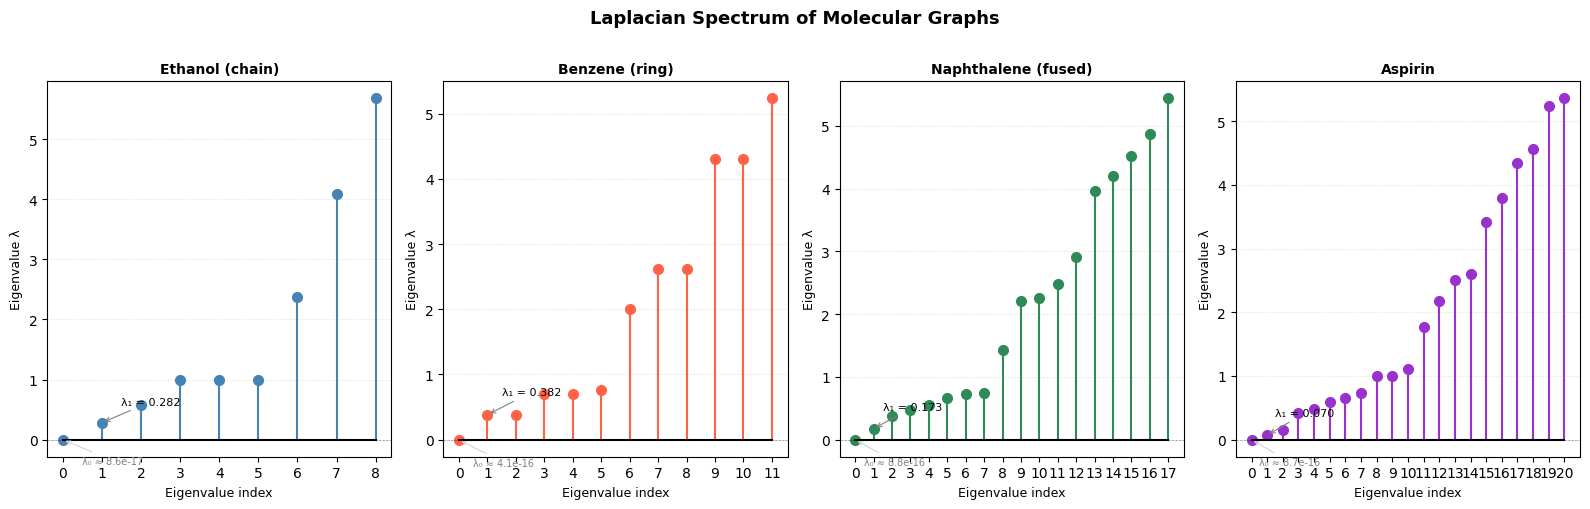

In [8]:
# Step 5: Plot the eigenvalue spectrum.
# Try a stem plot (matplotlib's plt.stem) or a scatter+line.
# Bonus: plot 2-3 molecules side-by-side and compare the Fiedler values.
# YOUR CODE HERE

molecules = {
    "Ethanol (chain)":       "CCO",
    "Benzene (ring)":        "c1ccccc1",
    "Naphthalene (fused)":   "c1ccc2ccccc2c1",
    "Aspirin":               "CC(=O)Oc1ccccc1C(=O)O",
}

spectra = {}
for name, smile in molecules.items(): 
    features, adjacency, labels = mol_to_graph(smile) 
    L = laplacian(adjacency) 
    eigenvalues = np.sort(np.linalg.eigvalsh(L))
    spectra[name] = eigenvalues

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
colors = ["steelblue", "tomato", "seagreen", "darkorchid"]

for ax, (name, eigs), color in zip(axes, spectra.items(), colors):
    indices = np.arange(len(eigs)) # [1, 2, 3..]
    
    # Stem plot
    markerline, stemlines, baseline = ax.stem(indices, eigs, linefmt=color,
                                               markerfmt='o', basefmt='k-')
    plt.setp(markerline, color=color, markersize=7)
    plt.setp(stemlines, linewidth=1.5)
    
    # Annotate Fiedler value (λ₁)
    if len(eigs) > 1:
        fiedler = eigs[1]
        ax.annotate(f"λ₁ = {fiedler:.3f}",
                    xy=(1, fiedler),
                    xytext=(1.5, fiedler + 0.3),
                    fontsize=8, color="black",
                    arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

    # Annotate λ₀ (should be ~0)
    ax.annotate(f"λ₀ ≈ {eigs[0]:.1e}",
                xy=(0, eigs[0]),
                xytext=(0.5, -0.4),
                fontsize=7, color="gray",
                arrowprops=dict(arrowstyle="->", color="lightgray", lw=0.8))

    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Eigenvalue index", fontsize=9)
    ax.set_ylabel("Eigenvalue λ", fontsize=9)
    ax.set_xticks(indices)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.4)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

fig.suptitle("Laplacian Spectrum of Molecular Graphs", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("spectrum_plot.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 6 — Normalized Laplacian (optional preview)

There's a sibling of `L` you'll meet later:

$$ L_{sym} = I - D^{-1/2} A \, D^{-1/2} $$

It's the same idea, but rescaled so that its eigenvalues lie in the interval `[0, 2]` regardless of how big the molecule is. **Graph Convolutional Networks (Kipf & Welling, 2017)** use this normalized form so the network's behavior doesn't blow up on densely connected graphs.

You don't need to implement it today. But it's worth knowing the formula exists, and that this matrix sits at the heart of every GCN forward pass.

In [9]:
# Optional: implement L_sym and compare its spectrum to the unnormalized L.
# YOUR CODE HERE


## Step 7 — Preview: spectral graph theory & GNNs

Here's the bridge to the rest of the roadmap.

A classical **graph convolution** is defined as multiplication in the eigenbasis of `L`:

$$ g \star x = U \, g(\Lambda) \, U^\top \, x $$

where `U` is the matrix of eigenvectors of `L` and `Λ` is the diagonal matrix of eigenvalues. In words: **transform `x` into the graph's frequency domain, multiply by a filter, transform back.**

This is the graph version of the convolution theorem from signal processing. Modern GNNs (GCN, ChebNet, GAT) are all approximations of this — chosen so you don't have to compute the full eigendecomposition for every molecule (which would be expensive on big datasets).

**Today's spectrum plot is your first look at the "frequency domain of a molecule."** When we build GNNs in Month 5–6, we'll be filtering atom features in this exact eigenbasis — whether the model authors say so or not.

## Open question to sit with

*Two molecules with the same number of atoms and bonds — say, two structural isomers — can still have different Laplacian spectra. So what, exactly, does the spectrum 'see' that the bond count alone doesn't?*

(Hint: think about how the bonds are *arranged*, not just how many there are. The spectrum is a fingerprint of the **connectivity pattern**, not just the connectivity count. This is also why two non-isomorphic graphs can occasionally share a spectrum — they're called *cospectral* graphs, and they're a famous edge case in spectral graph theory.)

---

*Part of the AI + Chemistry + SWE 12-Month Roadmap — March 2026 to March 2027*